In [22]:
# package imported
import requests
import schedule
import time
from datetime import datetime, timedelta
import requests
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
import scipy.stats as stats
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
import json


import random
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import statsmodels.api as sm
from datetime import datetime, timedelta

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten

import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from keras.models import Sequential
from keras.layers import Dense, Conv1D, Flatten
from keras.optimizers import Adam



from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
import scipy.stats as stats
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
import json

## 1. Store All SR Data
Drop the csv file from the website to this folder.

Functions below will store all the SR data from 2024-05-12 to the current date.

In [23]:
# Value Setting
current_date = datetime.now()
start_date = datetime(2024, 5, 21)
end_date = current_date - timedelta(days=1)

In [24]:
# Functions
# load data
def load_and_process_sr_data(start_date, end_date):
    # col names
    column_names = ['Date+T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 
                    'T11', 'T12', 'T13', 'T14', 'T15', 'F1', 'F2', 'F3', 'SR', 'A', 'Circ pump counter']

    dataframes = {}
    current_date = start_date

    while current_date <= end_date:
        file_name = f'data_{current_date.strftime("%Y-%m-%d")}.csv'
        date_key = current_date.strftime("%Y-%m-%d")

        try:
            data = pd.read_csv(file_name, header=None, names=column_names)

            # handle 'Date+T1' if concatenated
            if '-' in data.iloc[0, 0]:
                new_cols = data['Date+T1'].str.split(' T1:', expand=True)
                data['Date'] = new_cols[0]
                data['T1'] = new_cols[1].astype(float)
            else:
                data = data.reset_index().rename(columns={'index': 'Date'})

            data['SR'] = data['SR'].str.split(':').str[1].astype(float)
            data = data[['Date', 'SR']].dropna()

            dataframes[date_key] = data
        
        # if files not saved
        except FileNotFoundError:
            print(f"File not found: {file_name}")
        except Exception as e:
            print(f"Error reading {file_name}: {e}")

        current_date += timedelta(days=1)

    # Concatenate all DataFrames
    recent_data = pd.concat(dataframes.values())
    recent_data['Date'] = pd.to_datetime(recent_data['Date'], format="%Y-%m-%d %H:%M:%S", errors='coerce')
    recent_data['Dates'] = recent_data['Date'].dt.date
    recent_data['Time'] = recent_data['Date'].dt.time
    recent_data = recent_data[['Dates', 'Time', 'SR']].dropna().sort_values(by=['Dates'])
    return recent_data

In [25]:
# Read the error message to check which files are missing.
processed_data = load_and_process_sr_data(start_date, end_date)
all_SR = processed_data.sort_values(by=['Dates', 'Time'])

File not found: data_2024-08-01.csv
Error reading data_2024-08-02.csv: Error tokenizing data. C error: Expected 22 fields in line 206, saw 23

Error reading data_2024-08-07.csv: Error tokenizing data. C error: Expected 21 fields in line 5, saw 22

Error reading data_2024-08-11.csv: Error tokenizing data. C error: Expected 21 fields in line 2, saw 22

File not found: data_2024-08-13.csv
File not found: data_2024-08-14.csv
File not found: data_2024-08-15.csv
File not found: data_2024-08-16.csv
File not found: data_2024-08-17.csv
File not found: data_2024-08-18.csv
File not found: data_2024-08-19.csv
File not found: data_2024-08-20.csv
File not found: data_2024-08-21.csv
File not found: data_2024-08-22.csv
File not found: data_2024-08-23.csv
File not found: data_2024-08-24.csv
File not found: data_2024-08-25.csv


In [26]:
all_SR

,Dates,Time,SR
0,2024-05-21,00:00:02,84.41
1,2024-05-21,00:00:08,84.51
2,2024-05-21,00:00:14,84.45
3,2024-05-21,00:00:20,84.28
4,2024-05-21,00:00:26,84.13
...,...,...,...
19638,2024-08-12,15:08:50,239.17
19640,2024-08-12,15:08:56,239.25
19642,2024-08-12,15:09:01,238.30
19644,2024-08-12,15:09:07,236.55


## 2. Store Weather Data
### 2.1. Store the predicted weather
The predicted weather data will be stored automatically everyday at 0:00am. 

The file is named as **"weather_prediction_till_{next_date}.csv"**

In [27]:
yst_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/yesterday?unitGroup=metric&key=FLBEV2T2WUAPQGP2MP25GFASV&contentType=json"
last_7_day_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/last7days?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"
last_15_day_url =  "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/last15days?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"
tmr_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/tomorrow?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"
next_7_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/next7days?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"
next_30_day_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/next30days?unitGroup=metric&key=FLBEV2T2WUAPQGP2MP25GFASV&contentType=json"
next_24_hours_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/next24hours?unitGroup=metric&key=HJ2JWKPKSPZKWD64FVT9F7A6Z&contentType=json"
today_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/today?include=fcst%2Cobs%2Chistfcst%2Cstats%2Cdays%2Chours&key=FLBEV2T2WUAPQGP2MP25GFASV&contentType=json"

# self_define_url = f"https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/vancouver/{url_start_date}/{url_end_date}?unitGroup=metric&key=FLBEV2T2WUAPQGP2MP25GFASV&contentType=json"

In [33]:
def get_tmr_weather_df():
    # URL setup for tomorrow's weather data
    tmr_date = datetime.now() + timedelta(days=1)
    tmr_response = requests.get(tmr_url)

    # Check if the request was successful
    if tmr_response.status_code == 200:
        # Parse the JSON data
        weather_data = tmr_response.json()
        print("Data retrieved successfully!")
        
        # File path setup for saving the data
        tmr_file_path = f"{tmr_date.strftime('%Y-%m-%d')}_weather_data.json"
        with open(tmr_file_path, 'w') as f:
            json.dump(weather_data, f, indent=4)
        print("Weather data saved successfully!")
        
        # Load and parse the JSON data into a DataFrame
        with open(tmr_file_path, 'r') as file:
            tmr_json_data = json.load(file)
        
        # Initialize an empty list to hold all hourly data
        tmr_hourly_data = []
        
        # Loop through each day in the data
        for day in tmr_json_data['days']:
            # Extract each 'hour' from 'hours' array and enrich it with 'day' level data
            for hour in day['hours']:
                hour.update({
                    'date': day['datetime'],
                    'tempmax': day['tempmax'],
                    'tempmin': day['tempmin'],
                    'feelslikemax': day['feelslikemax'],
                    'feelslikemin': day['feelslikemin'],
                    'sunrise': day['sunrise'],
                    'sunset': day['sunset'],
                    'moonphase': day['moonphase'],
                    'conditions': day['conditions'],
                    'description': day['description'],
                    'icon': day['icon']
                })
                tmr_hourly_data.append(hour)
        
        # Create a DataFrame from the hourly data
        tmr_hourly_df = pd.DataFrame(tmr_hourly_data)
        
        # Define the columns of interest
        columns_of_interest = [
            'date', 'datetime', 'temp', 'tempmax', 'tempmin', 'feelslike', 'feelslikemax', 'feelslikemin', 
            'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'preciptype', 'snow', 'snowdepth',
            'windgust', 'windspeed', 'winddir', 'pressure', 'cloudcover', 'visibility', 
            'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset', 
            'moonphase', 'conditions', 'description', 'icon'
        ]

        # Reindex and rename the DataFrame
        tmr_hourly_df = tmr_hourly_df.reindex(columns=columns_of_interest).rename(columns={"date": "Dates", "datetime": "Time"})
        latitude = 49.2827

        def get_declination(day_of_year):
            return 23.45 * np.sin(np.deg2rad(360 * (284 + day_of_year) / 365))

        def get_hour_angle(time, longitude):
            total_hours = time.hour + time.minute / 60 + time.second / 3600
            solar_noon = 12 - (longitude / 15)
            return 15 * (total_hours - solar_noon)

        def solar_elevation(latitude, declination, hour_angle):
            latitude_rad = np.deg2rad(latitude)
            declination_rad = np.deg2rad(declination)
            hour_angle_rad = np.deg2rad(hour_angle)
            elevation_rad = np.arcsin(np.sin(latitude_rad) * np.sin(declination_rad) +
                                    np.cos(latitude_rad) * np.cos(declination_rad) * np.cos(hour_angle_rad))
            return np.rad2deg(elevation_rad)

        # tmr_hourly_df['Time'] = pd.to_datetime(tmr_hourly_df['Time'])
        # tmr_hourly_df['Sun Angle'] = tmr_hourly_df['Time'].apply(
        #     lambda x: solar_elevation(
        #         latitude,
        #         get_declination(x.timetuple().tm_yday),
        #         get_hour_angle(x, longitude=-123.1207)
        #     )
        # )
        
        # Apply the revision function before returning the DataFrame
        tmr_hourly_df = revise_tmr(tmr_hourly_df)
        
        return tmr_hourly_df
    else:
        print("Failed to retrieve data:", tmr_response.status_code)
        return None

# Function to revise the DataFrame based on UV index adjustments
def revise_tmr(tmr_hourly_df):
    tmr_hourly_df['hour'] = pd.to_datetime(tmr_hourly_df['Time'], format='%H:%M:%S').dt.hour
    uvindex_adjustment = 2  # Adjust this value as needed
    tmr_hourly_df.loc[tmr_hourly_df['hour'] >= 18, 'uvindex'] = 0        
    tmr_hourly_df.loc[(tmr_hourly_df['hour'] > 13) & (tmr_hourly_df['hour'] < 18) & (tmr_hourly_df['uvindex'] > 5), 'uvindex'] -= uvindex_adjustment
    tmr_hourly_df = tmr_hourly_df.drop(columns=['hour'])
    return tmr_hourly_df

# Function to store and update the weather prediction
def store_and_update_weather_prediction(tmr_weather_df):

    # Current date for the existing file and next day for the new file name
    current_date = datetime.now().strftime('%Y-%m-%d')
    next_date = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')
    
    # File paths
    existing_file_name = f'weather_prediction_till_{current_date}.csv'
    new_file_name = f'weather_prediction_till_{next_date}.csv'
    
    # Check if the current file exists
    if os.path.exists(existing_file_name):
        # Read the existing CSV file
        existing_data = pd.read_csv(existing_file_name)
        # Concatenate the new data
        updated_data = pd.concat([existing_data, tmr_weather_df], ignore_index=True)
        print("Existing data found and updated.")
    else:
        # If the file does not exist, just use the new data
        updated_data = tmr_weather_df
        print(f"No existing file found for today ({current_date}). A new file will be created.")
    
    # Save the updated data to the new file name
    updated_data.to_csv(new_file_name, index=False)
    
    # Delete the old file if it exists
    if os.path.exists(existing_file_name):
        os.remove(existing_file_name)
        print(f"Old file '{existing_file_name}' deleted successfully.")
    
    # Confirm the new file creation
    if os.path.exists(new_file_name):
        print(f"New file '{new_file_name}' created successfully with updated predictions.")
    else:
        print(f"Failed to create the new file '{new_file_name}'.")
a = get_tmr_weather_df()
a
# Main job function to be scheduled
# def job():
#     tmr_weather_df = get_tmr_weather_df()
#     if tmr_weather_df is not None:
#         store_and_update_weather_prediction(tmr_weather_df)

# # Schedule the job every day at 0:00 AM
# schedule.every().day.at("00:00").do(job)

# print("Scheduler started. Waiting for next run...")

# while True:
#     schedule.run_pending()
#     time.sleep(1)



Data retrieved successfully!
Weather data saved successfully!


,Dates,Time,temp,tempmax,tempmin,feelslike,feelslikemax,feelslikemin,dew,humidity,...,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon
0,2024-08-27,00:00:00,15.2,18.3,12.4,15.2,18.3,12.4,13.5,89.59,...,0.0,0.0,0.0,10.0,06:22:24,20:04:12,0.78,Rain,Clear conditions throughout the day with rain.,rain
1,2024-08-27,01:00:00,14.8,18.3,12.4,14.8,18.3,12.4,13.4,91.33,...,0.0,0.0,0.0,10.0,06:22:24,20:04:12,0.78,Rain,Clear conditions throughout the day with rain.,rain
2,2024-08-27,02:00:00,14.7,18.3,12.4,14.7,18.3,12.4,13.0,89.55,...,0.0,0.0,0.0,10.0,06:22:24,20:04:12,0.78,Rain,Clear conditions throughout the day with rain.,rain
3,2024-08-27,03:00:00,14.2,18.3,12.4,14.2,18.3,12.4,11.9,86.05,...,0.0,0.0,0.0,10.0,06:22:24,20:04:12,0.78,Rain,Clear conditions throughout the day with rain.,rain
4,2024-08-27,04:00:00,13.5,18.3,12.4,13.5,18.3,12.4,11.1,85.41,...,0.0,0.0,0.0,10.0,06:22:24,20:04:12,0.78,Rain,Clear conditions throughout the day with rain.,rain
5,2024-08-27,05:00:00,12.9,18.3,12.4,12.9,18.3,12.4,10.3,84.21,...,0.0,0.0,0.0,10.0,06:22:24,20:04:12,0.78,Rain,Clear conditions throughout the day with rain.,rain
6,2024-08-27,06:00:00,12.4,18.3,12.4,12.4,18.3,12.4,9.9,84.72,...,0.0,0.0,0.0,10.0,06:22:24,20:04:12,0.78,Rain,Clear conditions throughout the day with rain.,rain
7,2024-08-27,07:00:00,12.9,18.3,12.4,12.9,18.3,12.4,10.1,83.09,...,34.0,0.1,0.0,10.0,06:22:24,20:04:12,0.78,Rain,Clear conditions throughout the day with rain.,rain
8,2024-08-27,08:00:00,13.2,18.3,12.4,13.2,18.3,12.4,9.9,80.40,...,156.0,0.6,2.0,10.0,06:22:24,20:04:12,0.78,Rain,Clear conditions throughout the day with rain.,rain
9,2024-08-27,09:00:00,14.2,18.3,12.4,14.2,18.3,12.4,10.0,75.84,...,302.0,1.1,3.0,10.0,06:22:24,20:04:12,0.78,Rain,Clear conditions throughout the day with rain.,rain


### 2.2. Store the past weather

In [9]:
def update_weather_data(previous_csv_path, json_data_path):
    # Load the existing CSV data if available
    if os.path.exists(previous_csv_path):
        weather_df = pd.read_csv(previous_csv_path)
        # Ensure 'Dates' is in the correct datetime format
        weather_df['Dates'] = pd.to_datetime(weather_df['Dates'], errors='coerce')
        # Drop any rows where 'Dates' could not be converted
        weather_df.dropna(subset=['Dates'], inplace=True)
    else:
        print("No previous data file found, starting new dataset.")
        weather_df = pd.DataFrame()

    with open(json_data_path, 'r') as file:
        json_data = json.load(file)

    # Prepare new data from JSON to match the DataFrame structure
    new_rows = []
    for day in json_data['days']:
        for hour in day['hours']:
            hour.update({
                'Dates': day['datetime'],
                'Time': hour['datetime'],
                # Include other necessary columns here
                'tempmax': day['tempmax'],
                'tempmin': day['tempmin'],
                'feelslikemax': day['feelslikemax'],
                'feelslikemin': day['feelslikemin'],
                'sunrise': day['sunrise'],
                'sunset': day['sunset'],
                'moonphase': day['moonphase'],
                'conditions': day['conditions'],
                'description': day['description'],
                'icon': day['icon']
            })
            new_rows.append(hour)

    # Convert to DataFrame, handle 'Dates' and 'Time' formatting
    new_df = pd.DataFrame(new_rows)
    new_df['Dates'] = pd.to_datetime(new_df['Dates'], errors='coerce')
    new_df['Time'] = pd.to_datetime(new_df['Time']).dt.time
    new_df = new_df[['Dates', 'Time', 'temp', 'feelslike', 'dew', 'humidity', 'precip',
        'precipprob', 'preciptype', 'snow', 'snowdepth', 'windgust',
        'windspeed', 'winddir', 'cloudcover', 'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'conditions']]

    # Combine with existing data
    combined_df = pd.concat([weather_df, new_df], ignore_index=True)

    # Check for empty DataFrame
    if combined_df.empty:
        print("No data available to process.")
        return

    # Define new filename based on the date range
    start_date = combined_df['Dates'].min().strftime('%Y%m%d')
    end_date = combined_df['Dates'].max().strftime('%Y%m%d')
    new_filename = f"weather_{start_date}_to_{end_date}.csv"
    new_file_path = f'{new_filename}'

    # Save the combined data to a new file
    combined_df.to_csv(new_file_path, index=False)

    # Optionally delete the old CSV file if it's different from the new file
    if previous_csv_path != new_file_path and os.path.exists(previous_csv_path):
        os.remove(previous_csv_path)
        print(f"Deleted old data file: {previous_csv_path}")

    print(f"Data combined and saved successfully as {new_filename}")

# Scheduler function to update the weather data at midnight
# def job():
#     previous_csv_path = "your_previous_csv_file.csv"  # Replace with the actual path to the previous CSV file
#     json_data_path = "yst_file_path.json"  # Replace with the actual path to the JSON data file
#     update_weather_data(previous_csv_path, json_data_path)

# # Schedule the job every day at 0:00 AM
# schedule.every().day.at("00:00").do(job)

# print("Scheduler started. Waiting for next run...")

# while True:
#     schedule.run_pending()
#     time.sleep(1)


### 2.3. Get today's weather

In [10]:
def get_today_weather_df():
    # URL setup for tomorrow's weather data
    today_date = datetime.now()
    today_response = requests.get(today_url)

    # Check if the request was successful
    if today_response.status_code == 200:
        # Parse the JSON data
        weather_data = today_response.json()
        print("Data retrieved successfully!")
        
        # File path setup for saving the data
        today_file_path = f"{today_date.strftime('%Y-%m-%d')}_weather_data.json"
        with open(today_file_path, 'w') as f:
            json.dump(weather_data, f, indent=4)
        print("Weather data saved successfully!")
        
        # Load and parse the JSON data into a DataFrame
        with open(today_file_path, 'r') as file:
            today_json_data = json.load(file)
        
        # Initialize an empty list to hold all hourly data
        today_hourly_data = []
        
        # Loop through each day in the data
        for day in today_json_data['days']:
            # Extract each 'hour' from 'hours' array and enrich it with 'day' level data
            for hour in day['hours']:
                hour.update({
                    'date': day['datetime'],
                    'tempmax': day['tempmax'],
                    'tempmin': day['tempmin'],
                    'feelslikemax': day['feelslikemax'],
                    'feelslikemin': day['feelslikemin'],
                    'sunrise': day['sunrise'],
                    'sunset': day['sunset'],
                    'moonphase': day['moonphase'],
                    'conditions': day['conditions'],
                    'description': day['description'],
                    'icon': day['icon']
                })
                today_hourly_data.append(hour)
        
        # Create a DataFrame from the hourly data
        today_hourly_df = pd.DataFrame(today_hourly_data)
        
        # Define the columns of interest
        columns_of_interest = [
            'date', 'datetime', 'temp', 'tempmax', 'tempmin', 'feelslike', 'feelslikemax', 'feelslikemin', 
            'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'preciptype', 'snow', 'snowdepth',
            'windgust', 'windspeed', 'winddir', 'pressure', 'cloudcover', 'visibility', 
            'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset', 
            'moonphase', 'conditions', 'description', 'icon'
        ]

        
        # Reindex and rename the DataFrame
        today_hourly_df = today_hourly_df.reindex(columns=columns_of_interest).rename(columns={"date": "Dates", "datetime": "Time"})
        latitude = 49.2827

        def get_declination(day_of_year):
            return 23.45 * np.sin(np.deg2rad(360 * (284 + day_of_year) / 365))

        def get_hour_angle(time, longitude):
            total_hours = time.hour + time.minute / 60 + time.second / 3600
            solar_noon = 12 - (longitude / 15)
            return 15 * (total_hours - solar_noon)

        def solar_elevation(latitude, declination, hour_angle):
            latitude_rad = np.deg2rad(latitude)
            declination_rad = np.deg2rad(declination)
            hour_angle_rad = np.deg2rad(hour_angle)
            elevation_rad = np.arcsin(np.sin(latitude_rad) * np.sin(declination_rad) +
                                    np.cos(latitude_rad) * np.cos(declination_rad) * np.cos(hour_angle_rad))
            return np.rad2deg(elevation_rad)

        today_hourly_df['Time'] = pd.to_datetime(today_hourly_df['Time'])
        today_hourly_df['Sun Angle'] = today_hourly_df['Time'].apply(
            lambda x: solar_elevation(
                latitude,
                get_declination(x.timetuple().tm_yday),
                get_hour_angle(x, longitude=-123.1207)
            )
        )
        today_hourly_df['hour'] = pd.to_datetime(today_hourly_df['Time'], format='%H:%M:%S').dt.hour
        today_hourly_df.loc[today_hourly_df['hour'] >= 18, 'uvindex'] = 0        
        today_hourly_df.loc[(today_hourly_df['hour'] > 13) & (today_hourly_df['hour'] < 18) & (today_hourly_df['uvindex'] > 5), 'uvindex'] -= uvindex_adjustment
        today_hourly_df = today_hourly_df.drop(columns=['hour'])
        
        return today_hourly_df
    else:
        print("Failed to retrieve data:", today_response.status_code)
        return None

### 3.1. Merge into one dataframe

In [37]:
# get raw combined data, add sun angle, day/night, hourly SR
def preprocess_and_merge(all_SR, all_wea):
    # Convert Dates and Time to appropriate datetime formats
    all_SR['Dates'] = pd.to_datetime(all_SR['Dates'])
    all_SR['Time'] = pd.to_datetime(all_SR['Time'], format='%H:%M:%S').dt.time
    
    # Define average sunrise and sunset times for Vancouver by month
    sun_times = {
        'Jun': ('05:06', '21:10'),
        'May': ('05:12', '20:30'),
        'Apr': ('05:51', '19:45'),
        'Mar': ('06:37', '17:57'),
        'Feb': ('06:55', '17:09'),
        'Jan': ('07:45', '16:25'),
        'Dec': ('07:46', '16:14'),
        'Nov': ('07:07', '16:17'),
        'Oct': ('07:12', '17:53'),
        'Sep': ('06:28', '18:53'),
        'Aug': ('05:44', '19:58'),
        'Jul': ('05:11', '20:54')
    }
    
    # Classify each row as Daytime or Nighttime
    def classify_day_night(row, sun_times):
        month = row['Dates'].strftime('%b')
        sunrise, sunset = sun_times[month]
        sunrise = datetime.strptime(sunrise, '%H:%M').time()
        sunset = datetime.strptime(sunset, '%H:%M').time()
        if sunrise <= row['Time'] <= sunset:
            return 'Daytime'
        else:
            return 'Nighttime'
    
    all_SR['Day/Night'] = all_SR.apply(lambda row: classify_day_night(row, sun_times), axis=1)
    
    # Combine Dates and Time to create a Datetime column and round down to the nearest hour
    all_SR['Datetime'] = pd.to_datetime(all_SR['Dates'].astype(str) + ' ' + all_SR['Time'].astype(str)).dt.floor('H')
    
    # Group by the new 'Datetime' column and calculate the median SR and Day/Night status
    max_sr = all_SR.groupby('Datetime').agg({
        'SR': 'median',
        'Day/Night': 'first'
    }).reset_index()
    max_sr.rename(columns={'SR': 'Hourly SR (wh/m^2)'}, inplace=True)
    
    # Merge weather data and SR data
    all_wea['Dates'] = pd.to_datetime(all_wea['Dates'])
    all_wea['Time'] = pd.to_datetime(all_wea['Time'], format='%H:%M:%S').dt.time
    all_wea['Datetime'] = pd.to_datetime(all_wea['Dates'].astype(str) + ' ' + all_wea['Time'].astype(str))
    
    merged_df = pd.merge(max_sr, all_wea, on='Datetime', how='inner')
    merged_df['Hourly SR (wh/m^2)'] = merged_df.apply(lambda row: row['solarradiation'] if row['solarradiation'] <= 78 else row['Hourly SR (wh/m^2)'], axis=1)

    latitude = 49.2827 
    
    def get_declination(day_of_year):
        # Solar declination as a function of day of the year
        return 23.45 * np.sin(np.deg2rad(360 * (284 + day_of_year) / 365))
    
    def get_hour_angle(datetime_obj):
        # Calculate the hour angle at the given datetime
        longitude = -123.1207  # Vancouver's longitude
        time = datetime_obj.time()
        solar_noon_offset = (longitude / 15.0)  # Local standard time meridian adjustment
        hour_from_solar_noon = (time.hour + time.minute/60 + time.second/3600) - (12 - solar_noon_offset)
        return 15 * hour_from_solar_noon  # Hour angle changes by 15 degrees per hour
    
    def solar_elevation(date_time):
        # Calculate solar elevation
        declination = get_declination(date_time.timetuple().tm_yday)
        hour_angle = get_hour_angle(date_time)
        declination_rad = np.deg2rad(declination)
        latitude_rad = np.deg2rad(latitude)
        hour_angle_rad = np.deg2rad(hour_angle)
        elevation_rad = np.arcsin(np.sin(latitude_rad) * np.sin(declination_rad) + 
                                  np.cos(latitude_rad) * np.cos(declination_rad) * np.cos(hour_angle_rad))
        return np.rad2deg(elevation_rad)
    
    merged_df['Sun Elevation'] = merged_df['Datetime'].apply(solar_elevation)
    
    return merged_df

# combined data
yst_date = datetime.now() - timedelta(days=1)
tmr_date = datetime.now() + timedelta(days=1)
day_before_yst = datetime.now() - timedelta(days=2)
yst_date_str = yst_date.strftime('%Y-%m-%d')
updated_name = f'weather_20240420_to_{yst_date.strftime("%Y%m%d")}.csv'
previous_csv = f'weather_20240420_to_{day_before_yst.strftime("%Y%m%d")}.csv'
# json_path = f'{yst_date_str}_weather_data.json'
# update_weather_data(previous_csv, json_path)
# all_wea = pd.read_csv(updated_name).drop(columns='Unnamed: 0')
all_wea = pd.read_csv('weather_20240420_to_20240815.csv')
raw_total_df = preprocess_and_merge(all_SR, all_wea)

tmr_weather_df = get_tmr_weather_df()
revised_tmr_weather = revise_tmr(tmr_weather_df)

/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_35772/1451641153.py:37: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_SR['Datetime'] = pd.to_datetime(all_SR['Dates'].astype(str) + ' ' + all_SR['Time'].astype(str)).dt.floor('H')


Data retrieved successfully!
Weather data saved successfully!


### 3.2. Prediction Process

In [38]:
raw_total_df['Time_hour'] = raw_total_df['Time'].apply(lambda x: x.hour)
X_train = raw_total_df[['Time_hour', 'uvindex', 'feelslike']]
y_train = raw_total_df['Hourly SR (wh/m^2)']

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Define the Gradient Boosting Regressor model with a parameter grid for tuning
gbr = GradientBoostingRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 0.05],
    'max_depth': [3, 5]
}

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(
    gbr,
    param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

# Get the best model from the grid search
best_gbr = grid_search.best_estimator_

# Prepare the data for prediction
revised_tmr_weather['Time_hour'] = pd.to_datetime(revised_tmr_weather['Time']).dt.hour
X_tmr = revised_tmr_weather[['Time_hour', 'uvindex', 'feelslike']]

# Scale the features using the scaler fitted on the training data
X_tmr_scaled = scaler.transform(X_tmr)

# Predict the SR using the trained GBR model
revised_tmr_weather['Predicted Hourly SR (wh/m^2)'] = best_gbr.predict(X_tmr_scaled)


/var/folders/h0/8gdh0lxd4ynbp3ypwp6nwxmc0000gn/T/ipykernel_35772/3549571956.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  revised_tmr_weather['Time_hour'] = pd.to_datetime(revised_tmr_weather['Time']).dt.hour


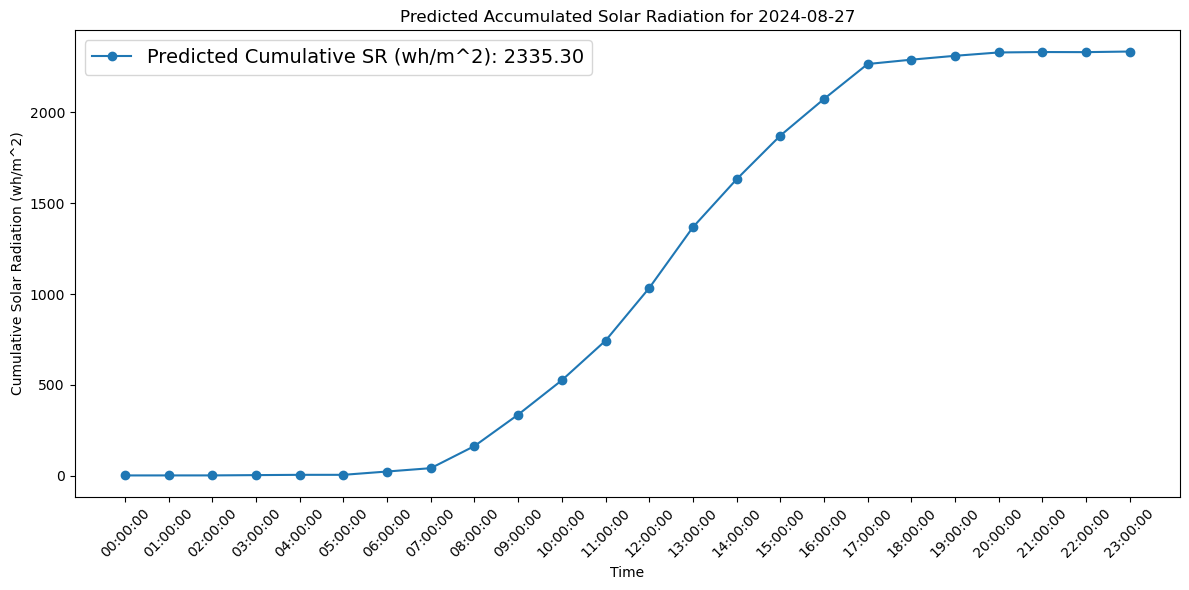

In [44]:
revised_tmr_weather = revised_tmr_weather.sort_values(by='Time')
revised_tmr_weather['Predicted Cumulative SR'] = revised_tmr_weather['Predicted Hourly SR (wh/m^2)'].cumsum()

def plot_predicted_sr(predicted_tmr_weather):
    plt.figure(figsize=(12, 6))

    # Calculate the total accumulated SR value
    total_accumulated_sr = predicted_tmr_weather['Predicted Cumulative SR'].iloc[-1]

    # Plot predicted cumulative SR
    plt.plot(predicted_tmr_weather['Time'], predicted_tmr_weather['Predicted Cumulative SR'], 
             label=f'Predicted Cumulative SR (wh/m^2): {total_accumulated_sr:.2f}', marker='o')

    # Adding titles and labels
    plt.title('Predicted Accumulated Solar Radiation for ' + str(tmr_date)[0:10])
    plt.xlabel('Time')
    plt.ylabel('Cumulative Solar Radiation (wh/m^2)')
    plt.xticks(rotation=45)
    plt.legend(fontsize=10)
    plt.legend(fontsize=14, loc='best') 

    # Display the plot
    plt.tight_layout()
    plt.show()

# Plot the results
plot_predicted_sr(revised_tmr_weather)

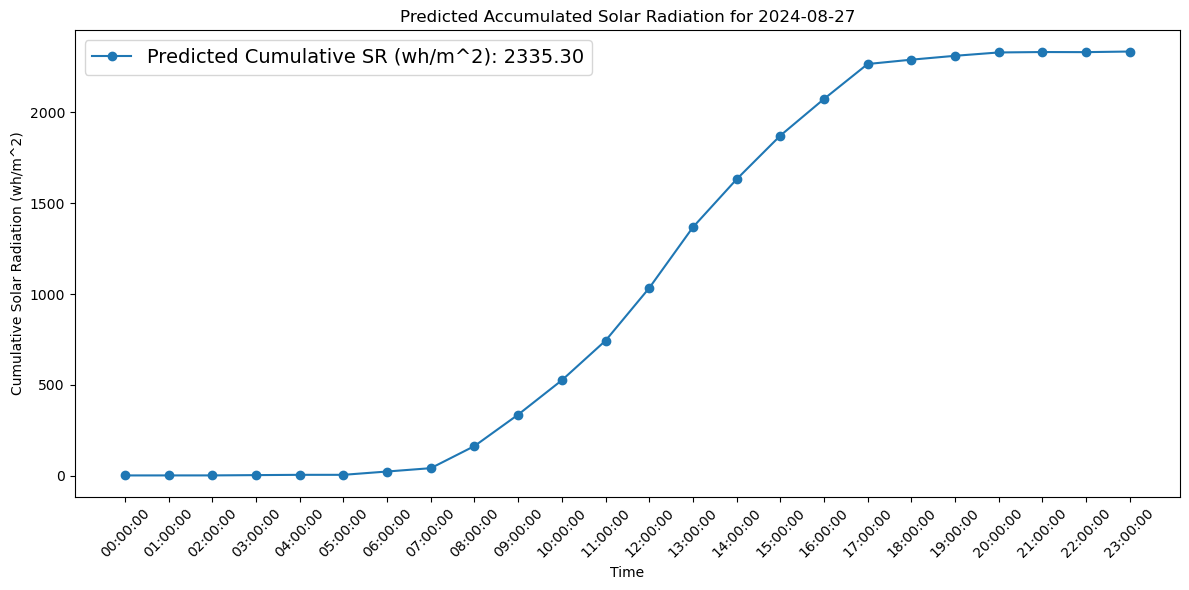

Predicted SR data appended to predicted_sr_data.csv


In [45]:
revised_tmr_weather = revised_tmr_weather.sort_values(by='Time')
revised_tmr_weather['Predicted Cumulative SR'] = revised_tmr_weather['Predicted Hourly SR (wh/m^2)'].cumsum()

def plot_predicted_sr(predicted_tmr_weather, tmr_date):
    plt.figure(figsize=(12, 6))

    # Calculate the total accumulated SR value
    total_accumulated_sr = predicted_tmr_weather['Predicted Cumulative SR'].iloc[-1]

    # Plot predicted cumulative SR
    plt.plot(predicted_tmr_weather['Time'], predicted_tmr_weather['Predicted Cumulative SR'], 
             label=f'Predicted Cumulative SR (wh/m^2): {total_accumulated_sr:.2f}', marker='o')

    # Adding titles and labels
    plt.title('Predicted Accumulated Solar Radiation for ' + str(tmr_date)[0:10])
    plt.xlabel('Time')
    plt.ylabel('Cumulative Solar Radiation (wh/m^2)')
    plt.xticks(rotation=45)
    plt.legend(fontsize=14, loc='best') 

    # Display the plot
    plt.tight_layout()
    plt.show()

    # Save the predictions to a CSV file (append mode)
    output_file_name = "predicted_sr_data.csv"
    
    # Check if the file exists to decide whether to write the header
    if not os.path.isfile(output_file_name):
        predicted_tmr_weather.to_csv(output_file_name, mode='a', index=False, header=True)
    else:
        predicted_tmr_weather.to_csv(output_file_name, mode='a', index=False, header=False)
    
    print(f"Predicted SR data appended to {output_file_name}")

# Example usage:
plot_predicted_sr(revised_tmr_weather, tmr_date)